## BEGINNER LEVEL TASK

#### Uploading & Loading Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ecommerce_customer_data_custom_ratios.csv to ecommerce_customer_data_custom_ratios.csv
Saving ecommerce_customer_data_large.csv to ecommerce_customer_data_large.csv


#### Reading the Dataset

In [ ]:
import pandas as pd

df1 = pd.read_csv('ecommerce_customer_data_custom_ratios.csv')
df2 = pd.read_csv('ecommerce_customer_data_large.csv')

print(df1.head())
print(df2.head())

   Customer ID        Purchase Date Product Category  Product Price  Quantity  \
0        46251  2020-09-08 09:38:32      Electronics             12         3   
1        46251  2022-03-05 12:56:35             Home            468         4   
2        46251  2022-05-23 18:18:01             Home            288         2   
3        46251  2020-11-12 13:13:29         Clothing            196         1   
4        13593  2020-11-27 17:55:11             Home            449         1   

   Total Purchase Amount Payment Method  Customer Age  Returns  \
0                    740    Credit Card            37      0.0   
1                   2739         PayPal            37      0.0   
2                   3196         PayPal            37      0.0   
3                   3509         PayPal            37      0.0   
4                   3452    Credit Card            49      0.0   

         Customer Name  Age  Gender  Churn  
0  Christine Hernandez   37    Male      0  
1  Christine Hernandez   3

#### Combining Both Datasets


In [ ]:
df = pd.concat([df1, df2], ignore_index=True)

print(df.shape)

(500000, 13)


#### Checking Data Types & Missing Values

In [ ]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            500000 non-null  int64  
 1   Purchase Date          500000 non-null  object 
 2   Product Category       500000 non-null  object 
 3   Product Price          500000 non-null  int64  
 4   Quantity               500000 non-null  int64  
 5   Total Purchase Amount  500000 non-null  int64  
 6   Payment Method         500000 non-null  object 
 7   Customer Age           500000 non-null  int64  
 8   Returns                405022 non-null  float64
 9   Customer Name          500000 non-null  object 
 10  Age                    500000 non-null  int64  
 11  Gender                 500000 non-null  object 
 12  Churn                  500000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 49.6+ MB


,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,94978
Customer Name,0


#### Generate Summary Statistics

In [ ]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,405022.000000,500000.000000,500000.000000
mean,25010.834166,254.701118,3.001916,2725.377964,43.869402,0.499343,43.869402,0.200008
std,14420.386990,141.653230,1.414717,1442.753398,15.357732,0.500000,15.357732,0.400006
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12545.000000,132.000000,2.000000,1477.000000,30.000000,0.000000,30.000000,0.000000
50%,25014.000000,255.000000,3.000000,2725.000000,44.000000,0.000000,44.000000,0.000000
75%,37473.250000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [ ]:
# Mean , Median , Mode

print("Mean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nMode")
print(df.mode().iloc[0])

Mean
Customer ID              25010.834166
Product Price              254.701118
Quantity                     3.001916
Total Purchase Amount     2725.377964
Customer Age                43.869402
Returns                      0.499343
Age                         43.869402
Churn                        0.200008
dtype: float64

Median
Customer ID              25014.0
Product Price              255.0
Quantity                     3.0
Total Purchase Amount     2725.0
Customer Age                44.0
Returns                      0.0
Age                         44.0
Churn                        0.0
dtype: float64

Mode
Customer ID                             8770
Purchase Date            2020-12-12 05:31:21
Product Category                    Clothing
Product Price                          119.0
Quantity                                 4.0
Total Purchase Amount                 4674.0
Payment Method                   Credit Card
Customer Age                            22.0
Returns                

### Observations

After exploring the dataset, I found that it contains customer purchase information along with customer details such as age, gender, payment method, and churn status. The dataset includes both numerical and categorical variables, making it suitable for analyzing customer behavior and purchase patterns.

The dataset appears well-structured and provides enough information to perform customer segmentation and churn analysis.

#### Creating 3 Visualizations



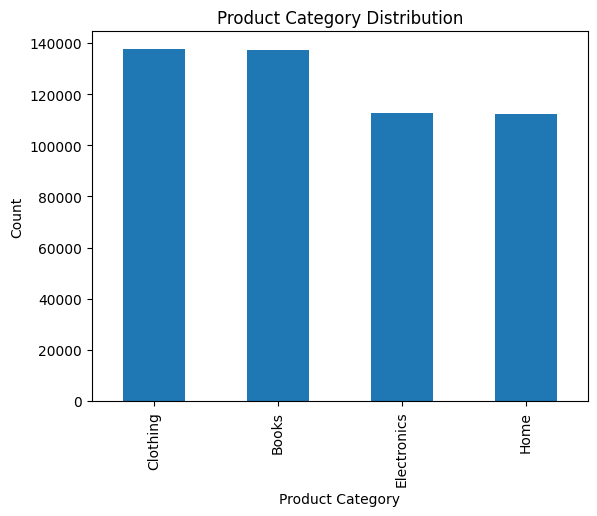

In [ ]:
# PRODUCT CATEGORY BAR CHART

import matplotlib.pyplot as plt

df['Product Category'].value_counts().plot(kind='bar')

plt.title('Product Category Distribution')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.show()

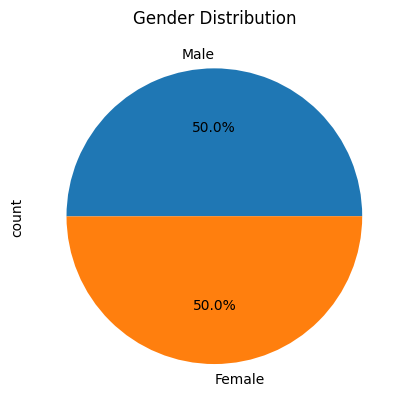

In [ ]:
# Gender Pie Chart

import matplotlib.pyplot as plt

df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Gender Distribution')
plt.show()


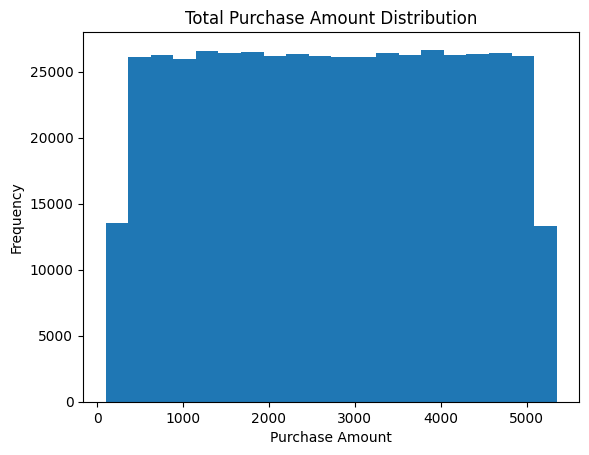

In [ ]:
# Purchase Amount Histogram

import matplotlib.pyplot as plt

plt.hist(df['Total Purchase Amount'], bins=20)

plt.title('Total Purchase Amount Distribution')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.show()


## DATA CLEANING

#### Copying our dataset

In [ ]:
df_clean = df.copy()

#### Checking Missing Values & Filling them

In [ ]:
# Check missing values
print(df.isnull().sum())

# Fill numerical columns
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify missing values are removed
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  94978
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

Missing Values After Cleaning:
Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64


#### Checking duplicate records

In [ ]:
print("Duplicates:", df_clean.duplicated().sum())

Duplicates: 0


#### Converting Date Column

In [ ]:
df_clean['Purchase Date'] = pd.to_datetime(df_clean['Purchase Date'])

# verify

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer ID            500000 non-null  int64         
 1   Purchase Date          500000 non-null  datetime64[ns]
 2   Product Category       500000 non-null  object        
 3   Product Price          500000 non-null  int64         
 4   Quantity               500000 non-null  int64         
 5   Total Purchase Amount  500000 non-null  int64         
 6   Payment Method         500000 non-null  object        
 7   Customer Age           500000 non-null  int64         
 8   Returns                500000 non-null  float64       
 9   Customer Name          500000 non-null  object        
 10  Age                    500000 non-null  int64         
 11  Gender                 500000 non-null  object        
 12  Churn                  500000 non-null  int6

#### Checking Data Consistency

In [ ]:
# Total Purchase Amount = Product Price × Quantity

df_clean['Calculated Amount'] = (df_clean['Product Price'] * df_clean['Quantity'])

df_clean[['Total Purchase Amount',
          'Calculated Amount']].head()

,Total Purchase Amount,Calculated Amount
0,740,36
1,2739,1872
2,3196,576
3,3509,196
4,3452,449


#### Detecting Outliers

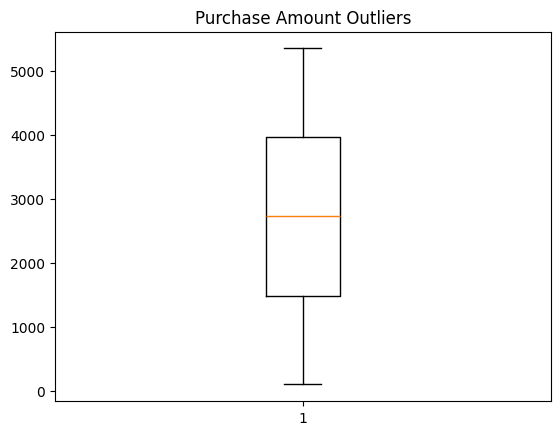

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df_clean['Total Purchase Amount'])
plt.title("Purchase Amount Outliers")
plt.show()

### Observations

The dataset was cleaned to ensure accurate analysis. Missing values and duplicate records were checked and handled appropriately. The Purchase Date column was converted into a proper date format so that time-based analysis could be performed.

After cleaning, the dataset became more reliable and ready for further analysis.

## FEATURE ENGINEERING

#### Feature 1 - Purchase Year

In [ ]:
df_clean['Purchase_Year'] = df_clean['Purchase Date'].dt.year

#### Feature 2 - Purchase Month

In [ ]:
df_clean['Purchase_Month'] = df_clean['Purchase Date'].dt.month

#### Feature 3 - Purchase Day

In [ ]:
df_clean['Purchase_Day'] = df_clean['Purchase Date'].dt.day

#### Feature 4 - Purchase Weekday

In [ ]:
df_clean['Purchase_Weekday'] = df_clean['Purchase Date'].dt.day_name()

#### Feature 5 - Return Flag

In [ ]:
df_clean['Return_Flag'] = (df_clean['Returns'].astype(str).str.lower().map({'yes':1, 'no':0}))

#### Feature 6 - Revenue Per Customer

In [ ]:
customer_revenue = (df_clean.groupby('Customer ID')['Total Purchase Amount'].sum().reset_index())
customer_revenue.columns = ['Customer ID','Customer_Revenue']
df_clean = df_clean.merge(customer_revenue,on='Customer ID')

In [ ]:
df_clean.to_csv("customer_behavior_cleaned.csv",index=False)

### Observations

New features such as Purchase Year, Purchase Month, Purchase Day, and Customer Revenue were created to gain deeper insights into customer behavior.

These features help in understanding when customers purchase products, how much revenue they generate, and whether their return behavior affects their future purchases.

## CUSTOMER SEGMENTATION USING RFM ANALYSIS

#### Creating RFM Table

In [ ]:
import pandas as pd

# Latest date in dataset
snapshot_date = df_clean['Purchase Date'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,58,4,9781
2,74,9,24469
3,89,12,32010
4,127,9,16541
5,171,13,22293


#### Creating RFM Scores

In [ ]:
# Divide customers into 4 groups

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4 , labels=[4,3,2,1])

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4 , labels=[1,2,3,4])

rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4 , labels=[1,2,3,4])

#### Creating Overall RFM Score

In [ ]:
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str))
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
1,58,4,9781,3,1,1,311
2,74,9,24469,3,2,2,322
3,89,12,32010,3,3,3,333
4,127,9,16541,2,2,1,221
5,171,13,22293,2,4,2,242


#### Creatintg Customer Segments

In [ ]:
def customer_segment(row):

    if row['RFM_Score'] == '444':
        return 'Champions'

    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'

    elif row['R_Score'] >= 3:
        return 'Potential Loyalists'

    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'At Risk'

    else:
        return 'Others'

rfm['Segment'] = rfm.apply(customer_segment,axis=1)

#### Viewing Segments Counts

In [ ]:
rfm['Segment'].value_counts()

,count
Segment,
At Risk,14653
Loyal Customers,11503
Potential Loyalists,10346
Others,10255
Champions,3241


#### Visualize Segments

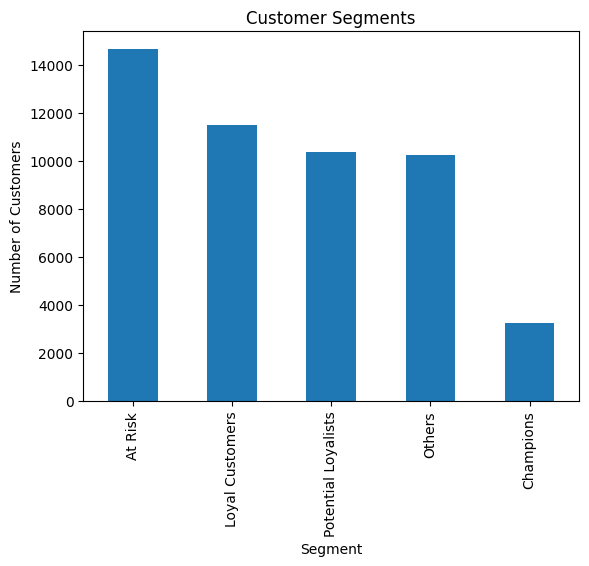

In [ ]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar')

plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()

#### Profile Each Segment

In [ ]:
segment_profile = rfm.groupby('Segment').agg({'Recency':'mean' , 'Frequency':'mean' , 'Monetary':'mean'})
segment_profile

,Recency,Frequency,Monetary
Segment,,,
At Risk,257.788985,7.291613,19906.058213
Champions,19.465597,14.663067,41797.069423
Loyal Customers,48.309137,12.133096,32460.854299
Others,193.227694,12.196685,33296.576597
Potential Loyalists,44.775759,7.828049,21330.718055



### Observations

RFM analysis helped group customers according to their purchasing behavior.

The Champions segment contains customers who purchase frequently, spend more money, and have made recent purchases. These customers are the most valuable for the business.

The Loyal Customers segment consists of customers who regularly purchase products and contribute consistently to revenue.

Potential Loyalists are customers who have shown recent activity and may become loyal customers in the future.

The At-Risk segment includes customers who have not purchased recently and may stop engaging with the business if no retention efforts are made.

## VISUALIZE PURCHASE PATTERNS AND RETENTION TRENDS

#### Purchase Trend Over Time (Line Chart)

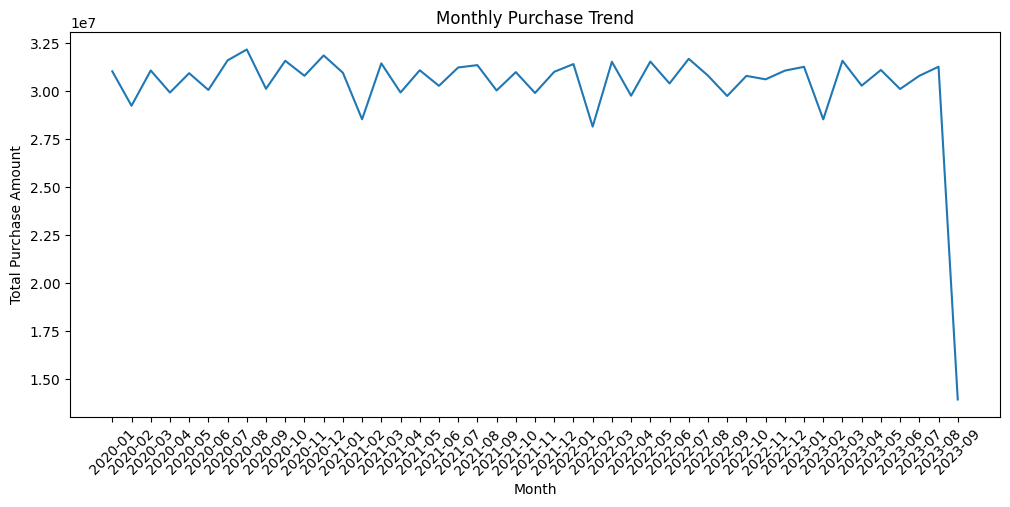

In [ ]:
# This shows whether sales are increasing or decreasing over time.

import matplotlib.pyplot as plt

monthly_sales = df_clean.groupby(df_clean['Purchase Date'].dt.to_period('M')['Total Purchase Amount'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title('Monthly Purchase Trend')
plt.xlabel('Month')
plt.ylabel('Total Purchase Amount')
plt.xticks(rotation=45)
plt.show()

### Observations

The monthly purchase trend shows how customer spending changes over time. Some months have higher purchase activity than others, indicating fluctuations in customer demand.

These trends can help businesses identify peak sales periods and plan marketing campaigns more effectively.

#### Product Category Performance (Bar Chart)

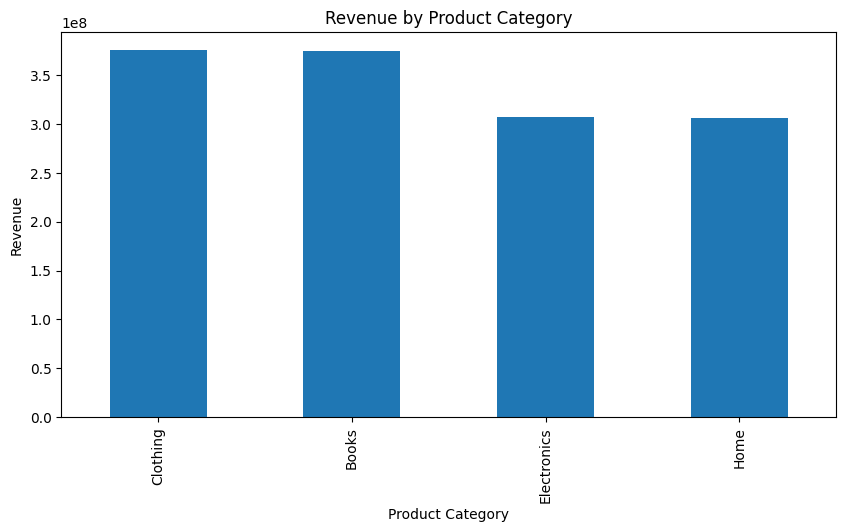

In [ ]:
category_sales = df_clean.groupby('Product Category')['Total Purchase Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
category_sales.plot(kind='bar')
plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.show()

### Observations

The chart shows that some product categories generate more revenue than others. Customers appear to have stronger preferences for certain categories, which contribute significantly to overall sales.

Focusing on high-performing categories may help increase business revenue.

#### Payment Method Analysis

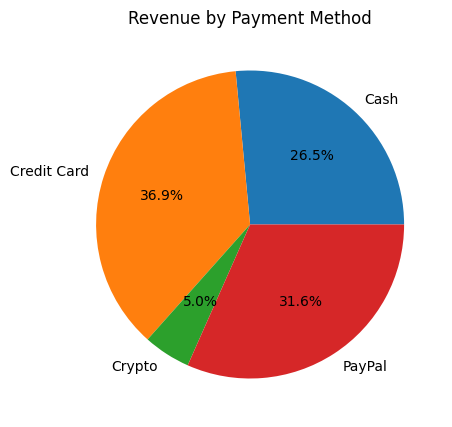

In [ ]:
payment_sales = df_clean.groupby('Payment Method')['Total Purchase Amount'].sum()

plt.figure(figsize=(8,5))
payment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Revenue by Payment Method')
plt.ylabel('')
plt.show()

### Observations

The payment method analysis shows which payment options customers prefer most. Understanding these preferences can help businesses improve the customer checkout experience and provide more convenient payment options.

#### Churn Distribution

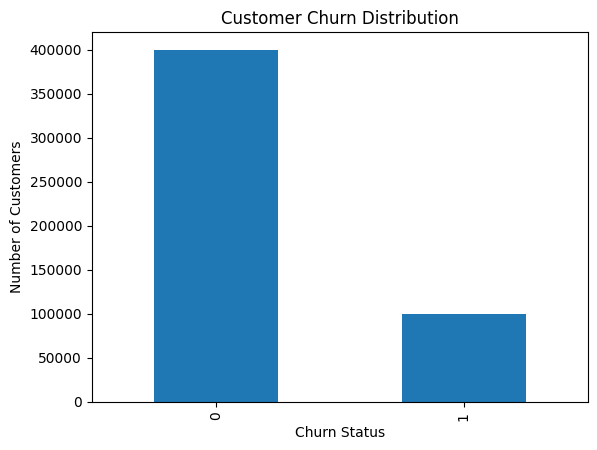

In [ ]:
df_clean['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

### Observations

The churn distribution helps understand how many customers remain active and how many have stopped purchasing.

A higher number of retained customers indicates good customer engagement, while a larger churn group suggests that customer retention strategies may need improvement.

#### Churn by Product Category

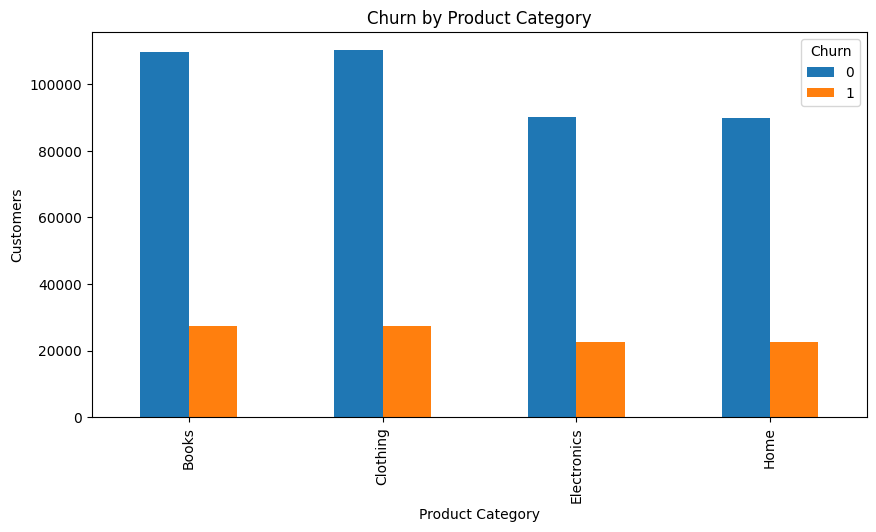

In [ ]:
import pandas as pd

churn_category = pd.crosstab(df_clean['Product Category'],df_clean['Churn'])

churn_category.plot(kind='bar',figsize=(10,5))

plt.title('Churn by Product Category')
plt.ylabel('Customers')
plt.show()

### Observations

The chart shows that churn is not equally distributed across all product categories. Some categories have a higher number of churned customers than others.

This may indicate differences in customer satisfaction, product quality, or customer expectations across categories.

#### Churn by Age Group

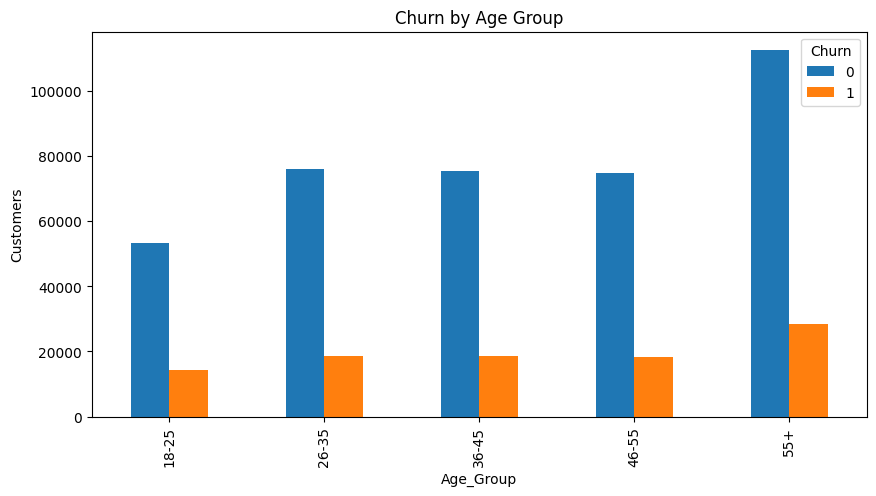

In [ ]:
df_clean['Age_Group'] = pd.cut(df_clean['Age'],bins=[18,25,35,45,55,100],labels=['18-25','26-35','36-45','46-55','55+'])

age_churn = pd.crosstab(df_clean['Age_Group'],df_clean['Churn'])

age_churn.plot(kind='bar',figsize=(10,5))

plt.title('Churn by Age Group')
plt.ylabel('Customers')
plt.show()

### Observations

Customer retention behavior varies across different age groups. Certain age groups appear more likely to continue purchasing, while others show a greater tendency to churn.

Understanding these differences can help businesses create age-specific marketing and retention strategies.

#### Return Behavior vs Churn

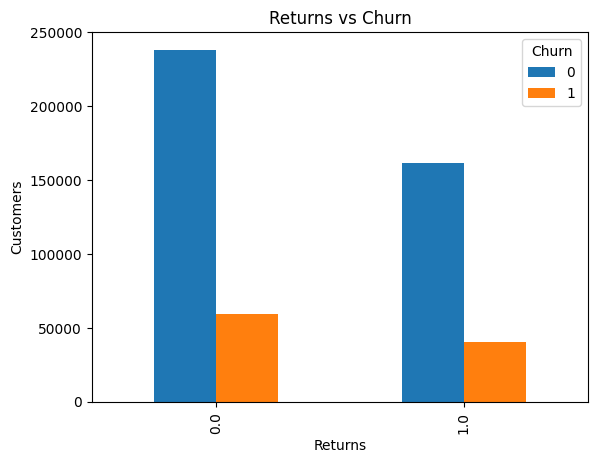

In [ ]:
return_churn = pd.crosstab(df_clean['Returns'],df_clean['Churn'])

return_churn.plot(kind='bar')

plt.title('Returns vs Churn')
plt.ylabel('Customers')
plt.show()

### Observations

The relationship between returns and churn suggests that customers who frequently return products may be more likely to stop purchasing in the future.

Reducing product return issues and improving customer satisfaction may help lower churn rates.

### Insight
Customers in the Champions segment contribute the highest revenue and show strong purchase frequency. These customers should be prioritized through loyalty programs and exclusive offers.

# Conclusion

In this project, customer transaction data was analyzed to understand purchasing behavior and customer retention patterns.

The dataset was cleaned and enhanced through feature engineering, making it suitable for analysis. RFM analysis helped identify different customer segments based on their purchasing habits. Purchase pattern visualizations revealed trends in customer spending, product preferences, and payment behavior.

Churn analysis highlighted factors that may influence customer retention, including age groups, product categories, and return behavior.

Overall, the insights generated from this analysis can help businesses make better decisions, improve customer satisfaction, and develop more effective customer retention strategies.